# Deep Learning &mdash; Assignment 6

Assignment for week 6 of the 2022 Deep Learning course (NWI-IMC070) of the Radboud University.

-----

**Names:**

**Group:**

-----

**Instructions:**
* Fill in your names and the name of your group.
* Answer the questions and complete the code where necessary.
* Keep your answers brief, one or two sentences is usually enough.
* Re-run the whole notebook before you submit your work.
* Save the notebook as a PDF and submit that in Brightspace together with the `.ipynb` notebook file.
* The easiest way to make a PDF of your notebook is via File > Print Preview and then use your browser's print option to print to PDF.

## Objectives

In this assignment you will
1. Build a graph neural network, using pytorch geometric
2. Compare a GNN with other network architectures
3. Compare different GNN layers and aggregation functions

## Required software

As before you will need these libraries:
* `torch`, `torch-sparse`, `torch-scatter`, and `torch-geometric` for PyTorch,
* `d2l`, the library that comes with [Dive into deep learning](https://d2l.ai) book.

The recommended way to install these libraries is described in the [torch-geometric installation instructions](https://pytorch-geometric.readthedocs.io/en/latest/notes/installation.html).

In [1]:
# Replace ${TORCH} and ${CUDA} with your torch and cuda versions.
# Or remove the -f argument to compile from source
#
# !pip install torch-scatter torch-sparse -f https://data.pyg.org/whl/torch-2.0.1%2Bcu117.html
# !pip install torch-geometric

In [2]:
%config InlineBackend.figure_formats = ['png']
%matplotlib inline

from d2l import torch as d2l
import itertools
import numpy as np
import matplotlib.pyplot as plt
import torch
import torch_geometric
from torch import nn
from torch.nn import Linear, Dropout
from torch.nn import functional as F
from torch_geometric.datasets import Planetoid
from torch_geometric.transforms import NormalizeFeatures
from torch_geometric.nn import GCNConv, SAGEConv, GraphConv

## 6.1 A node classification dataset (1 point)

In this assignment we will be working on a node classification problem using the Citeseer dataset. This is a graph dataset that contains bag-of-words representation of documents and citation links between the documents. So there is an edge between document $i$ and document $j$ if one cites the other. This is an undirected edge.

In [3]:
dataset = Planetoid(root='data', name='Citeseer', transform=NormalizeFeatures())

**(a) How many graphs are there in this dataset? How large are they (in terms of nodes and edges)?<span style="float:right"> (1 point)</span>**

In [105]:
# TODO: your answer here
print(f'Number of graphs: {len(dataset)}')
print(f'Number of nodes and edges in graph: {dataset.data.num_nodes,dataset.data.num_edges}')


Number of graphs: 1
Number of nodes and edges in graph: (3327, 9104)


In fact, we will continue the rest of this notebook using the first graph from the dataset.

In [38]:
data = dataset[0]  # Get the first graph object.

We will be use a subset of the nodes for training, and another subset for testing.
These subsets are indicated by `data.train_mask` and `data.test_mask` respectively.

## 6.2 MLP for node classification (6 points)

In theory, we should be able to classify documents based only on their content, that is, using the bag-of-words features, without taking the graph structure into account.

We can verify that by constructing a simple node-wise multilayer perceptron with a single hidden layer. This network does not use the edge information at all.

**(a) Complete the code below.<span style="float:right"> (2 points)</span>**

The network should have 2 linear layers. The hidden layer should have size `hidden_channels`, use ReLU activations, and use dropout with a dropout rate of 0.1. Don't use an activation function after the final layer.

Hint: avoid using `Sequential`, it will make the assignment harder later on.

In [46]:
class MLP(torch.nn.Module):
    def __init__(self, num_features, num_classes, hidden_channels = 16):
        super().__init__()
        self.linear_1 = Linear(num_features, hidden_channels)
        self.linear_2 = Linear(hidden_channels, num_classes)
        self.dropout = Dropout(0.1)

    def forward(self, x, edge_index):
        x = self.linear_1(x)
        x = F.relu(x)
        x = self.dropout(x)
        x = self.linear_2(x)
        return x
        

**(b) Complete the training loop below.<span style="float:right"> (2 points)</span>**

Hint: compute the loss only on the training nodes.

Hint 2: `data.x` contains the features for each node, `data.y` contains their labels.

Hint 3: `model()` takes two parameters: a tensor of node features, and a tensor of edges. See the `test_accuracy` function.

In [84]:
device = d2l.try_gpu()

def accuracy(pred_y, true_y):
    correct = pred_y.argmax(dim=1) == true_y
    return int(correct.sum()) / len(true_y)

def test(model, data):
    loss_fn = torch.nn.CrossEntropyLoss()
    with torch.no_grad():
        model.eval()
        out = model(data.x, data.edge_index)
        # Compute loss and accuracy only on the 'test' nodes
        test_loss = loss_fn(out[data.test_mask], data.y[data.test_mask]).item()
        test_acc = accuracy(out[data.test_mask], data.y[data.test_mask])
        # Compute loss and accuracy only on the 'train' nodes
        train_loss = loss_fn(out[data.train_mask], data.y[data.train_mask]).item()
        train_acc = accuracy(out[data.train_mask], data.y[data.train_mask])
        return train_loss, train_acc, test_loss, test_acc

def train(model, data, lr=0.01, weight_decay=5e-4, epochs=400, plot=True):
    model = model.to(device)
    data = data.to(device)
    optimizer = torch.optim.Adam(model.parameters(), lr=lr, weight_decay=weight_decay)
    loss_fn = torch.nn.CrossEntropyLoss()
    if plot:
        animator = d2l.Animator(xlabel='epoch', xlim=[1, epochs], figsize=(10, 5),
                                legend=['train loss', 'train accuracy', 'test loss', 'test accuracy'])
    
    for epoch in range(1, epochs+1):
        model.train()
        # TODO: Compute and optimize loss
        optimizer.zero_grad()
        y_pred = model(data.x, data.edge_index)
        loss = loss_fn(y_pred[data.train_mask], data.y[data.train_mask])
        loss.backward()
        optimizer.step()
        
        # Compute test accuracy, and plot
        if plot and epoch % 10 == 0:
            train_loss, train_acc, test_loss, test_acc = test(model, data)
            animator.add(epoch + 1, (train_loss, train_acc, test_loss, test_acc))
    
    # Print final accuracy
    train_loss, train_acc, test_loss, test_acc = test(model, data)
    print(f'Train loss: {train_loss:.4f}, Train accuracy: {train_acc:.4f}')
    print(f'Test loss: {test_loss:.4f}, Test accuracy: {test_acc:.4f}')

**(c) Now construct and train an MLP on this dataset.<span style="float:right"> (1 point)</span>**

Train loss: 0.0792, Train accuracy: 1.0000
Test loss: 1.2047, Test accuracy: 0.5970


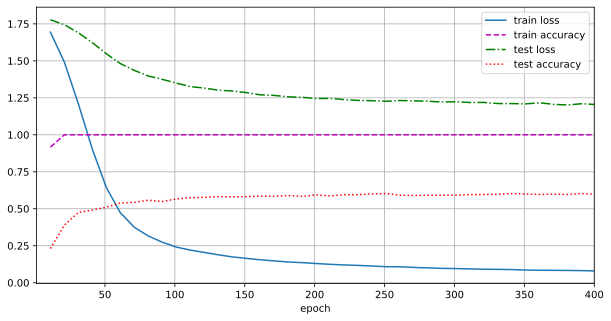

In [76]:
mlp_model = train(MLP(data.num_features, dataset.num_classes), data)

**(d) The MLP network does not use the citation information at all. Give a way to incorporate the edge information without using a graph neural network?<span style="float:right"> (1 point)</span>**

Note that the method should still work for arbitrary citation graphs.

To incorporate the edge information, we would use knowledge about neighbouring nodes. In our case, we could calculate the number of connected nodes, or give the mean and std values of the neighbouring nodes. That would to some extent give more information to the network.

## 6.3 A graph convolutional neural network (3 points)

Next, we will use a graph neural network based on the Graph Convolutional Network approach, which was introduced in the paper [Semi-Supervised Classification with Graph Convolutional Networks](https://arxiv.org/pdf/1609.02907.pdf).

**(a) Implement a graph convolutional neural network, by replacing the linear layers in the MLP with [`GCNConv` layers](https://pytorch-geometric.readthedocs.io/en/latest/modules/nn.html#torch_geometric.nn.conv.GCNConv), and train the network.<span style="float:right"> (1 point)</span>**

The network should have two `GCNConv` layers. The rest of the architecture should stay as close as possible to the MLP.

Train loss: 0.1778, Train accuracy: 1.0000
Test loss: 0.9346, Test accuracy: 0.7160


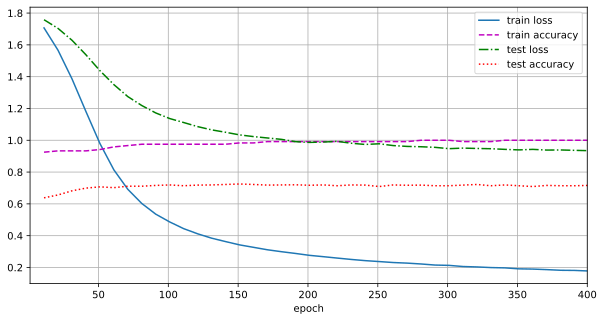

In [85]:
class GCN(torch.nn.Module):
    def __init__(self, num_features, num_classes, hidden_channels = 16):
        super().__init__()
        self.GCN_1 = GCNConv(num_features, hidden_channels)
        self.GCN_2 = GCNConv(hidden_channels, num_classes)
        self.dropout = Dropout(0.1)

    def forward(self, x, edge_index):
        x = self.GCN_1(x, edge_index)
        x = F.relu(x)
        x = self.dropout(x)
        x= self.GCN_2(x, edge_index)
        return x
        

# TODO: construct and train the model
gcn_model = GCN(data.num_features, dataset.num_classes)
train(gcn_model, data)

**(b) Compare the results of the MLP and the GCN. Which model is better?<span style="float:right"> (1 point)</span>**

MLP:

Train loss: 0.0792, Train accuracy: 1.0000

Test loss: 1.2047, Test accuracy: 0.5970

GCN:

Train loss: 0.1874, Train accuracy: 0.9917

Test loss: 0.9402, Test accuracy: 0.7130

We see that the test loss and accuracy are better for the GCN, making it a better model.

**(c) Has the GCN training converged? Can you expect higher test accuracies by training longer? Explain your answer.<span style="float:right"> (1 point)</span>**

The training seems to have mostly converged. The test accuracy does not improve after ~100 epochs, whereas the loss does keep on decreasing; we do not expect higher test accuracies.

## 6.4 Comparing GNN layers (8 points)

Two graph layers that are interesting to compare are [`SAGEConv`](https://pytorch-geometric.readthedocs.io/en/latest/modules/nn.html#torch_geometric.nn.conv.SAGEConv) and [`GraphConv`](https://pytorch-geometric.readthedocs.io/en/latest/modules/nn.html#torch_geometric.nn.conv.GraphConv). Aside from one of them supporting weighted graphs, these models differ only in the accumulation function.

**(a) Look at the documentation for these two layers. What is the difference in the accumulation function?<span style="float:right"> (1 point)</span>**

In default settings, SAGEConv takes the mean of the features of neighbors, whereas the GraphConv simply adds/sums them.

To avoid having to copy the GNN structure every time, we can make our code generic in the type of layer to use.

**(b) Make a generic graph neural network, that uses layers of type `layer_type`.<span style="float:right"> (1 point)</span>**

Hint: you can construct layers with `my_layer = layer_type(in_size, out_size, **layer_args)`.

In [86]:
class GNN(torch.nn.Module):
    def __init__(self, layer_type, num_features, num_classes, hidden_channels=16, **layer_args):
        super().__init__()
        self.my_layer1 = layer_type(num_features, hidden_channels, **layer_args)
        self.my_layer2 = layer_type(hidden_channels, num_classes, **layer_args)
        self.dropout = Dropout(0.1)

    def forward(self, x, edge_index):
        x = self.my_layer1(x, edge_index)
        x = F.relu(x)
        x = self.dropout(x)
        x = self.my_layer2(x, edge_index)
        return x
        

**(c) Train a SAGEConv network and a GraphConv network.<span style="float:right"> (no points)</span>**

Train loss: 0.0504, Train accuracy: 1.0000
Test loss: 0.9275, Test accuracy: 0.6980


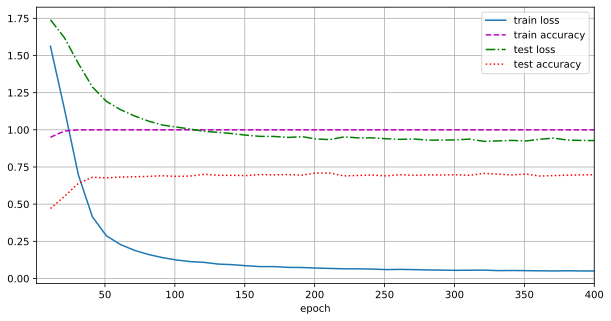

In [87]:
# TODO: construct and train a GNN with SAGEConv layers
sageconv_model = GNN(SAGEConv, data.num_features, dataset.num_classes)
train(sageconv_model, data)

Train loss: 0.0234, Train accuracy: 1.0000
Test loss: 1.3930, Test accuracy: 0.6550


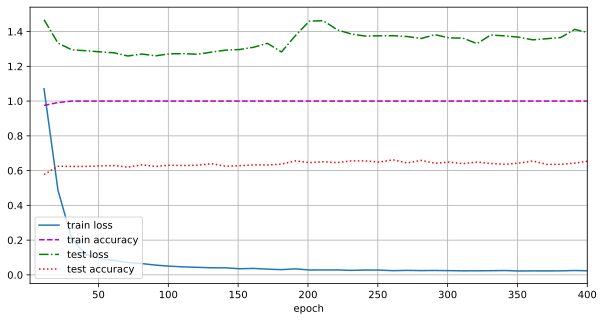

In [88]:
# TODO: construct and train a GNN with GraphConv layers
graphconv_model = GNN(GraphConv, data.num_features, dataset.num_classes)
train(graphconv_model, data)

**(d) Compare the performance of these two models, and also compare them to the GCN.<span style="float:right"> (1 point)</span>**

Hint: look at the test loss.

GCN:

Train loss: 0.1874, Train accuracy: 0.9917

Test loss: 0.9402, Test accuracy: 0.7130


SAGEConv:

Train loss: 0.0504, Train accuracy: 1.0000

Test loss: 0.9275, Test accuracy: 0.6980

GraphConv:

Train loss: 0.0234, Train accuracy: 1.0000

Test loss: 1.3930, Test accuracy: 0.6550

From this we can see that the graphconv model is worse than both GCN and SAGEConv in terms of the test loss. The test loss of the GCN is worse than for SAGEConv, but the test accuracy is better; however, this is marginal and can be attributed to fluctuations. 

**(e) Can you explain the observation in the previous question by looking at the aggregation functions? Why is one of them worse than the others?<span style="float:right"> (1 point)</span>**

Summing, as used by GraphConv, is not ideal. It has a strong dependence on the number of connected nodes, which can strongly differ between nodes, skewing the parameter. Taking the average is a nicer way of dealing with this problem, as the number of connected nodes does not explicitly influence the value.

In fact, it is possible to use different aggregation functions, by passing `aggr=` to the network constructor.

**(f) Compute the performance for `GraphConv` networks with `'mean'`, `'sum'`, `'min'`, `'max'`, and `'std'` aggregation.<span style="float:right"> (1 point)</span>**

Hint: train with `plot=False` to only show the final loss and accuracy.

Hint 2: if the performance is the same for all methods, there is most likely a bug in your `GNN` code.

In [96]:
aggrs = ['mean','sum','min','max','std']
for aggr_method in aggrs:
    print(f'Aggregation method: {aggr_method}')
    model = GNN(GraphConv, data.num_features, dataset.num_classes, aggr=aggr_method)
    train(model,data,plot=False)

Aggregation method: mean
Train loss: 0.0533, Train accuracy: 1.0000
Test loss: 0.9292, Test accuracy: 0.7100
Aggregation method: sum
Train loss: 0.0224, Train accuracy: 1.0000
Test loss: 1.3043, Test accuracy: 0.6660
Aggregation method: min
Train loss: 0.0494, Train accuracy: 1.0000
Test loss: 1.0381, Test accuracy: 0.6710
Aggregation method: max
Train loss: 0.0325, Train accuracy: 1.0000
Test loss: 1.0125, Test accuracy: 0.6660
Aggregation method: std
Train loss: 0.0682, Train accuracy: 1.0000
Test loss: 1.1533, Test accuracy: 0.6360


**(g) Which three aggregation methods are the worst? For each one, explain why that one would not work well.<span style="float:right"> (3 points)</span>**

Hint: bag-of-word features are very sparse.

sum, std, and min are the worst. 

sum, as we already explained, does not appropriately take into account the possibility of disproportionality between number of connected nodes.

std doesn't work well because it does not say much about the actual values of the neighbours, merely the std between them; this is not very informative.

min also does not make a lot of sense: the bag-of-word features are sparse, and so often the minimum will simply be zero.

## 6.5 Discussion (3 points)

**(a) Our training procedure gets the entire graph, including test nodes. Is it possible for the model to cheat using leaked information?<span style="float:right"> (1 point)</span>**

No, the labels are not passed for the test nodes, therefore no leakage can occur.

**(b) Can the GCN and GNN networks use information from neighbors of neighbors to classify a node? Briefly explain your answer.<span style="float:right"> (1 point)</span>**

Yes they do - using the graph convolutional layers we use neighboring information; adding another layer as we did would imply using neighbors' neighbor information as well.

**(c) Do you think the trained model will generalize to other graphs? Motivate your answer.<span style="float:right"> (1 point)</span>**

Really depends on the graph which it is consequently used on. If the graph is similar to the one used for training, the trained model might still work, but the likelihood is small. 

## The end

Well done! Please double check the instructions at the top before you submit your results.

*This assignment has 21 points.*
<span style="float:right;color:#aaa;font-size:10px;"> Version f502e67 / 2023-10-04</span>